In [6]:
from typing_extensions import Hashable
class Value:
  # a simplistic copy of pytorch autograd

  def __init__(self,data,_children=(),_op=""):
    self.data=data
    self.grad=0.0
    self._backward=lambda : None # this means some function
    self._op=_op
    self._prev=set(_children)


  # function definitions
  def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

  def __mul__(self, other):
      other = other if isinstance(other, Value) else Value(other)
      out = Value(self.data * other.data, (self, other), '*')

      def _backward():
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad
      out._backward = _backward

      return out

  def __pow__(self, other):
      assert isinstance(other, (int, float)), "only supporting int/float powers for now"
      out = Value(self.data**other, (self,), f'**{other}')

      def _backward():
          self.grad += (other * self.data**(other-1)) * out.grad
      out._backward = _backward

      return out

  def relu(self):
      out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

      def _backward():
          self.grad += (out.data > 0) * out.grad
      out._backward = _backward

      return out

    # graph construction for backprogation
  def backward(self):
    topo=[] # dependency graph building for gradient backpropagation
    visited=set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for u in v._prev:
          build_topo(u) # this means this is a post order traversal first we visit the childrens and then at last the vertex itself
        topo.append(v)

    build_topo(self)

    self.grad=1.0 # initial condition

    for u in reversed(topo): # means we process the last vertex first
      # jsut call backward it will build itself
      u._backward()


  def __neg__(self): # -self
      return self * -1

  def __radd__(self, other): # other + self
      return self + other

  def __sub__(self, other): # self - other
      return self + (-other)

  def __rsub__(self, other): # other - self
      return other + (-self)

  def __rmul__(self, other): # other * self
      return self * other

  def __truediv__(self, other): # self / other
      return self * other**-1

  def __rtruediv__(self, other): # other / self
      return other * self**-1

  def __repr__(self):
      return f"Value(data={self.data}, grad={self.grad})"




# Important Notes About Lambda, Closures, and Intermediate Objects in Autograd

In Python, every expression like `a*b + c` creates intermediate temporary objects internally, even if we never explicitly assign them to variables. In an autograd engine, each operation (`+`, `*`, `pow`, etc.) constructs a new `Value` object representing a node in the computation graph.

For example:

```python
y = 5 + (7 * x)

In [7]:
x = Value(3)

y = 5 + (7 * x)
# even though intermediate values are not explicity defined python internally

print("Forward value:")
print(y)

y.backward()

print("\nGradient of x:")
print(x.grad)

Forward value:
Value(data=26, grad=0.0)

Gradient of x:
7.0


In [8]:
!pip install graphviz

from graphviz import Digraph

Forward value:
Value(data=26, grad=0.0)

Gradient of x:
7.0


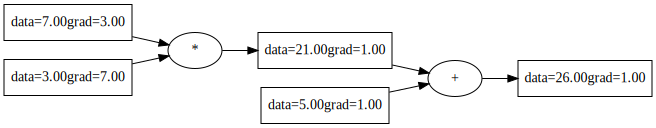

In [9]:
def trace(root):
    nodes = set()
    edges = set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges



def draw_dot(root):

    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:

        uid = str(id(n))

        # value node
        dot.node(
            name=uid,
            label=f"data={n.data:.2f}\ngrad={n.grad:.2f}",
            shape='record'
        )

        # operation node
        if n._op:
            op_id = uid + n._op

            dot.node(name=op_id, label=n._op)
            dot.edge(op_id, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


x = Value(3)
y = 5 + (7 * x)

print("Forward value:")
print(y)

y.backward()

print("\nGradient of x:")
print(x.grad)


draw_dot(y)

# **MakeMore**

Text(0.5, 1.0, 'First letter Distribution')

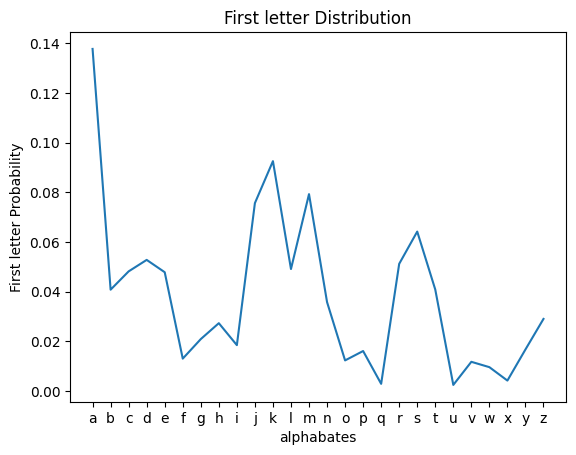

In [10]:
# i will try to code a bigram model myself before looking at the actual implementation
# so a very basic model would be that on the training data set we find the probability of next word given some word
# and then just for a sequence of word we can choose from the given probability distribution in the same proportion

# we just need to build a lot of cdf's


# we can extract a lot of information , like
# what's the most probable word for the starting of a sentence
# or what the most probable word for the i th position given that the word length is j
# and what's the most probable word after this one


# first word distribution

import pandas as pd
import numpy as np
import string
from collections import OrderedDict
import matplotlib.pyplot as plt



with open("names.txt") as f:
    lines = f.readlines()

fw_dist={}

for ch in string.ascii_lowercase:
  fw_dist[ch]=0.0

total_count=0.0

for i in lines:
  total_count+=1.0
  if not i[0].isalpha():
    continue
  fw_dist[i[0].lower()]+=1.0

# normalise the distribution
for ch in string.ascii_lowercase:
  fw_dist[ch]=(fw_dist[ch]/total_count)

# let's plot the pdf

alphabates=list()
val=list()

for ch in string.ascii_lowercase:
  alphabates.append(ch)
  val.append(fw_dist[ch])

plt.plot(alphabates, val)

# Adding labels and title
plt.xlabel('alphabates')
plt.ylabel('First letter Probability')
plt.title('First letter Distribution')



In [11]:
ranked = sorted(fw_dist.items(), key=lambda x: x[1], reverse=True)

print(ranked)

[('a', 0.1376705272687541), ('k', 0.09249836106515157), ('m', 0.07923079324446665), ('j', 0.07560952767458558), ('s', 0.0641525926388412), ('d', 0.052758093216370615), ('r', 0.05116598507788843), ('l', 0.049074392033215744), ('c', 0.04813785783410857), ('e', 0.04779446196110261), ('t', 0.040832891081072645), ('b', 0.04077045546779883), ('n', 0.035775606405893924), ('z', 0.029001342365685388), ('h', 0.027284363000655575), ('g', 0.020884712640089908), ('i', 0.018449723722411264), ('y', 0.016701526550744545), ('p', 0.01607717041800643), ('f', 0.013017825367589672), ('o', 0.012299815814940843), ('v', 0.011737895295476539), ('w', 0.009583866637530048), ('x', 0.004183186089345363), ('q', 0.0028720382105953237), ('u', 0.002434988917678644)]


In [12]:
# let's now find the Posterior probability of letter given some letter
# again initialise a dictoinary
# we would make this efficient by doing this in a linear scan of the given file
# actually we can just include '\n' in this new matrix this will help us caputre infomation about both starting and ending of words
# and this essentially means that we would also have the information about names

chars = string.ascii_lowercase + '\n'

pp_letters={}
letter_count={} # for efficeint normalisation

for c in chars:
  letter_count[c]=0.0 # define float for floating operations
  pp_letters[c]={} # initialise an empty dictoionary
  # again now a nested loop for intialising a lot of zeroes
  for m in chars:
    pp_letters[c][m]=0.0


for line in lines:
    line = line.lower()
    # start of word captures the previos frequency distribution
    first = line[0]
    if first.isalpha():
        pp_letters['\n'][first] += 1
        letter_count['\n'] += 1
    for idx in range(len(line) - 1):
        ch = line[idx]
        nxt = line[idx + 1]
        if not ch.isalpha() and ch != '\n':
          continue
        if not nxt.isalpha() and nxt != '\n':
          continue
        pp_letters[ch][nxt] += 1
        letter_count[ch] += 1

# normalisinig

for c in pp_letters:
    if letter_count[c] == 0:
        continue
    for nxt in pp_letters[c]:
        pp_letters[c][nxt] /= letter_count[c]



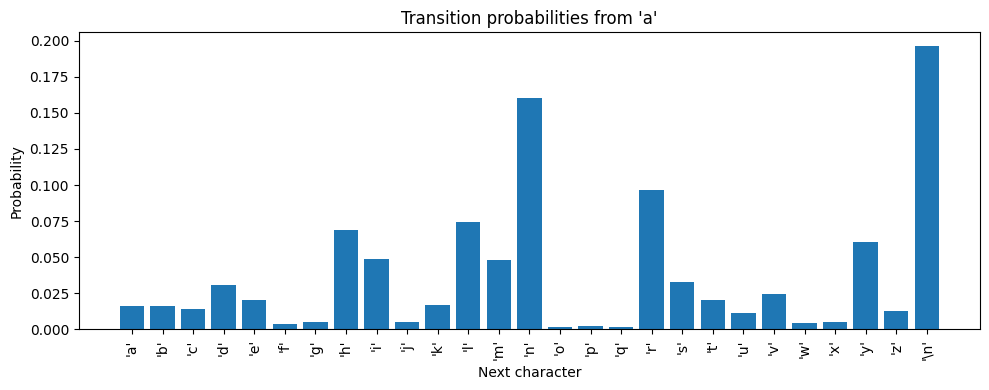

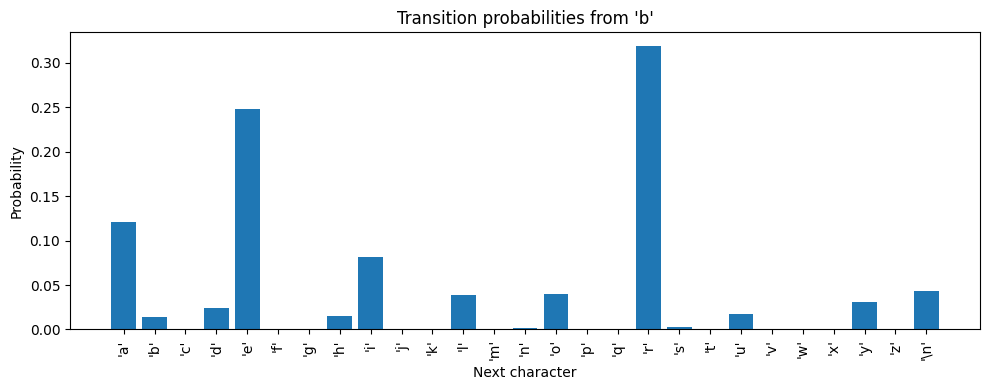

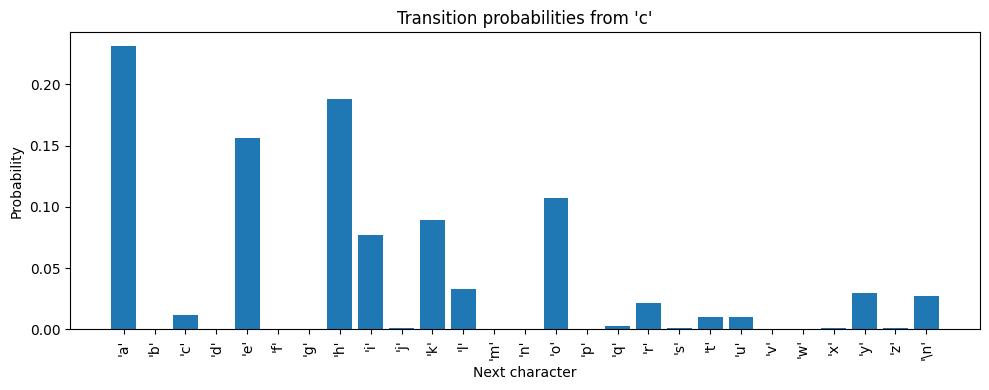

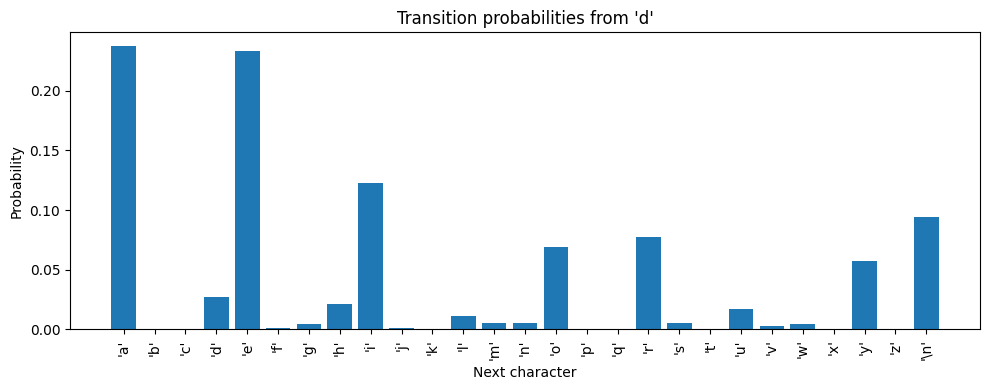

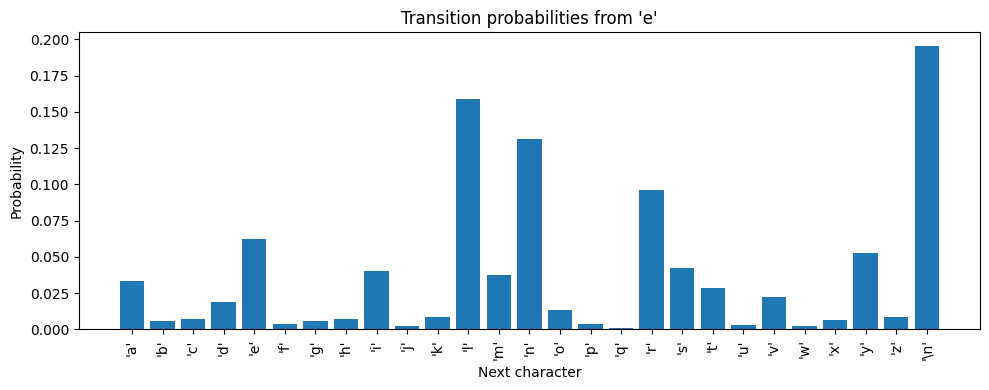

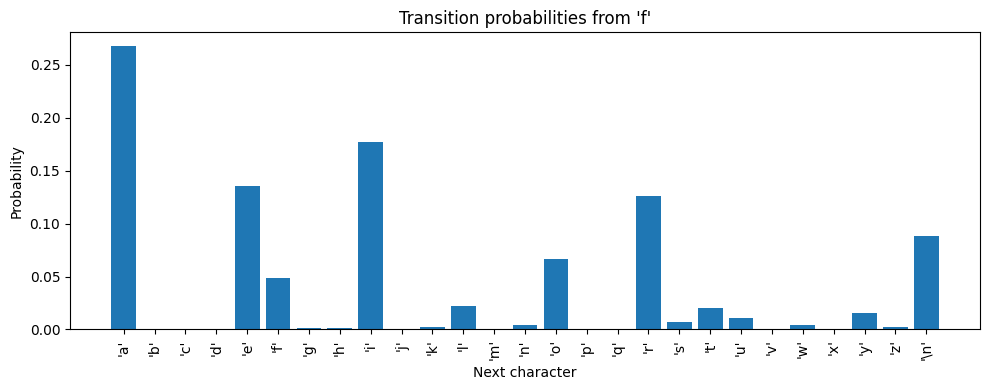

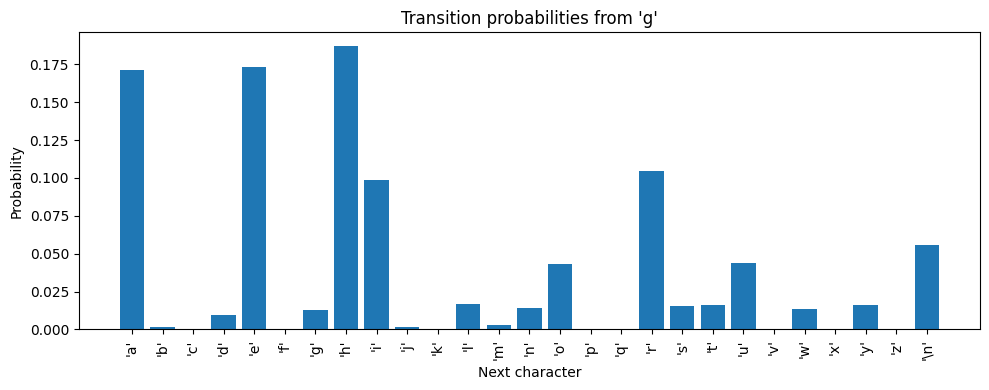

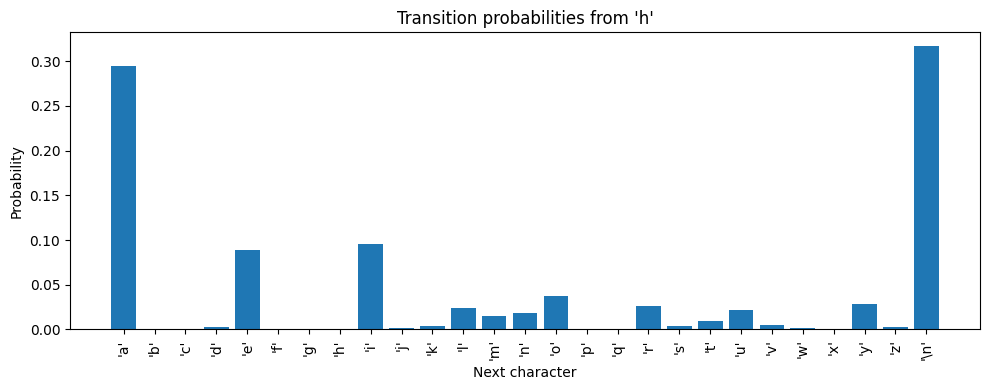

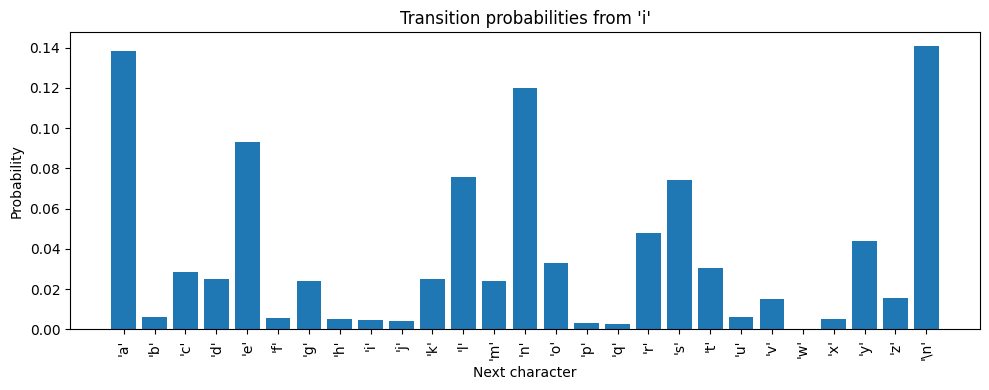

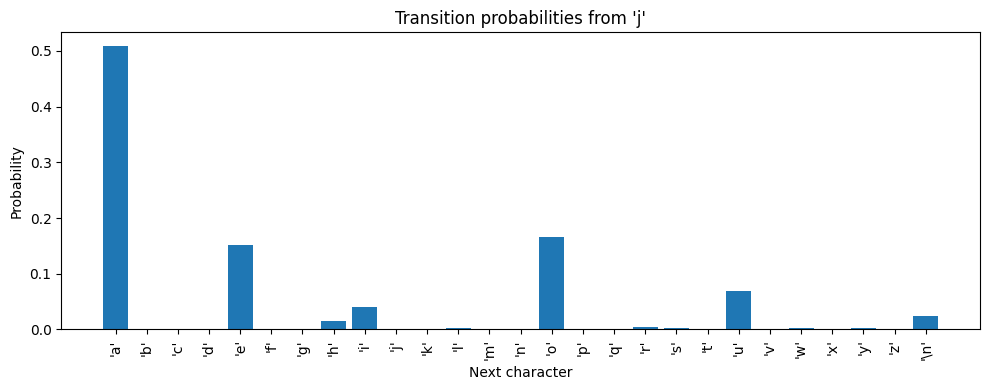

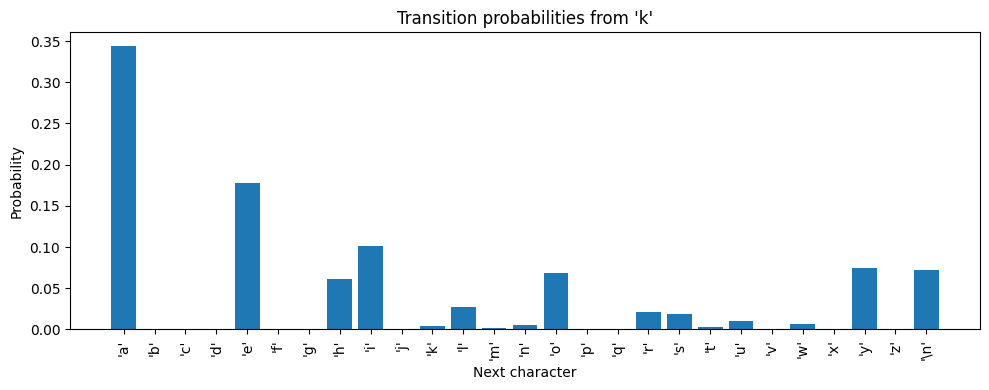

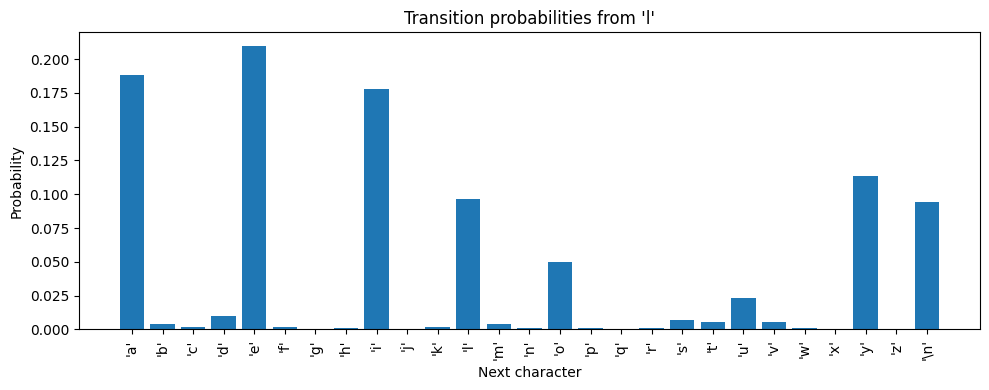

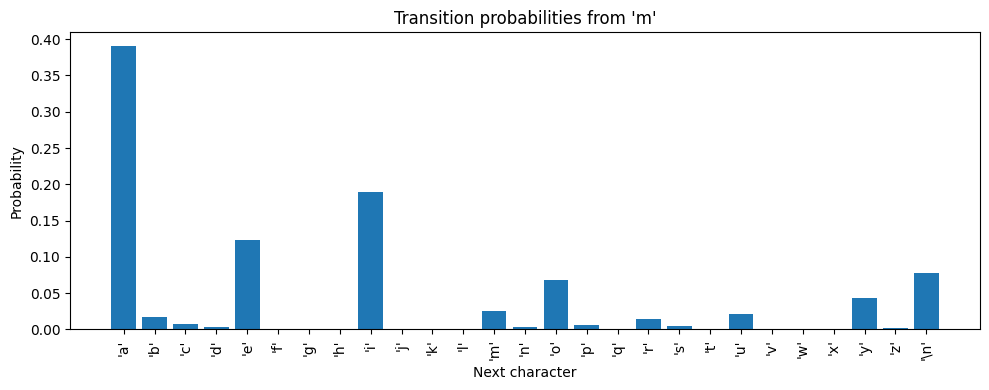

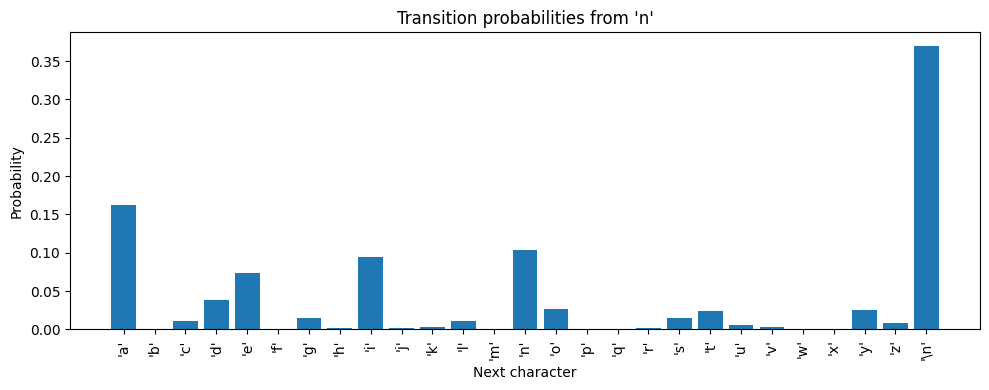

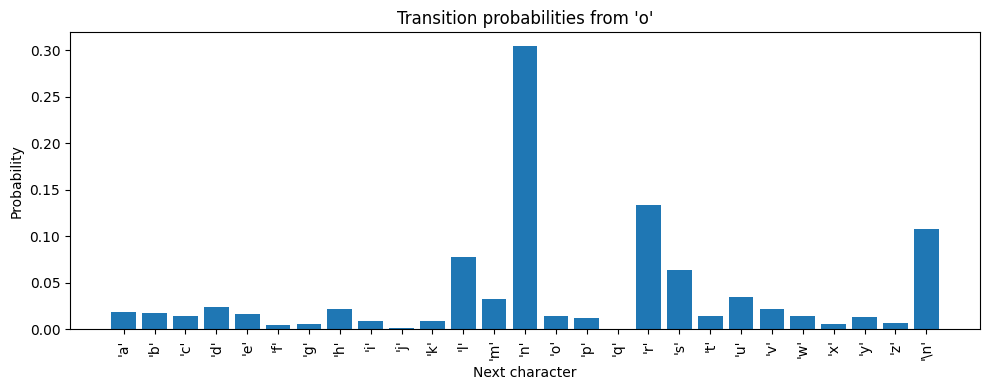

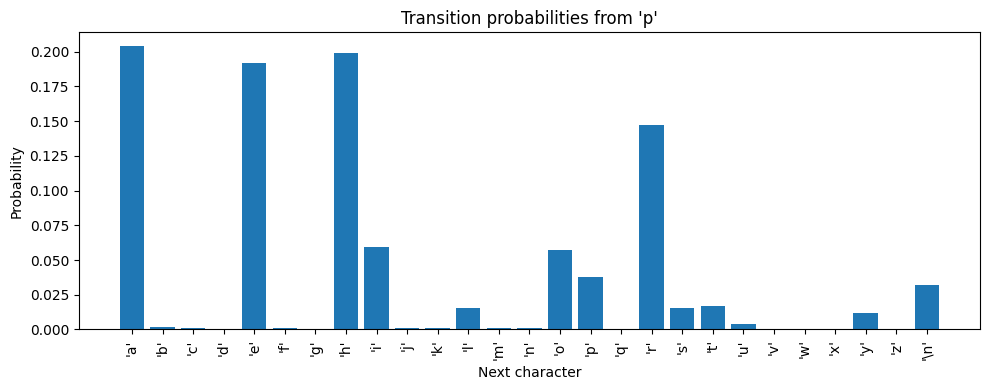

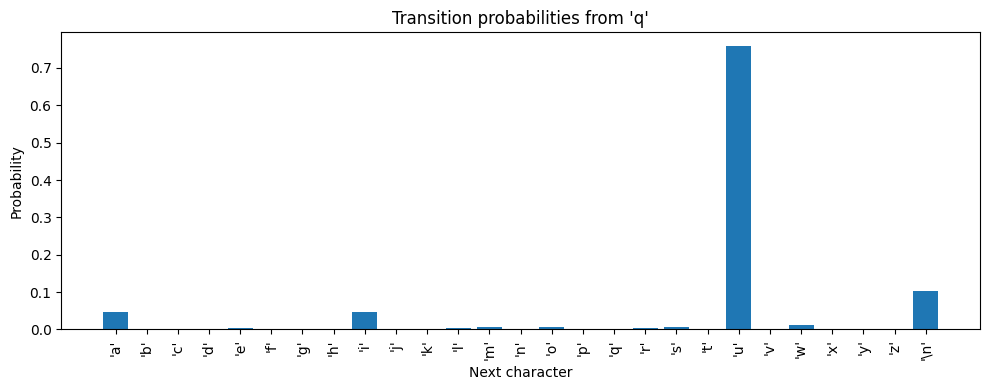

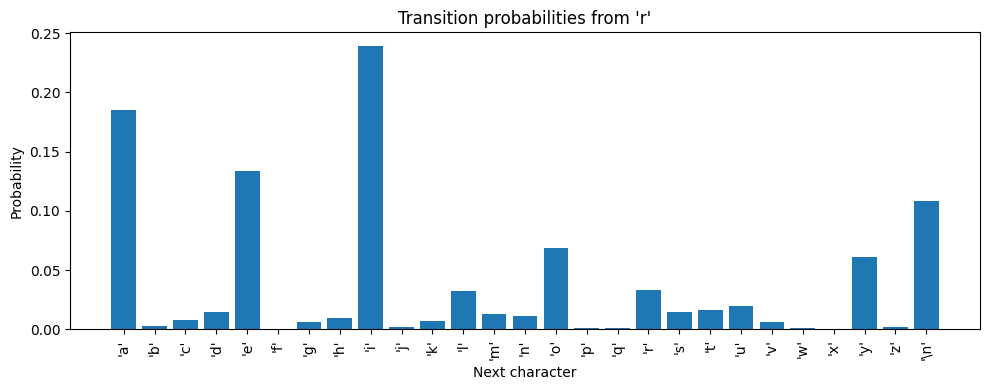

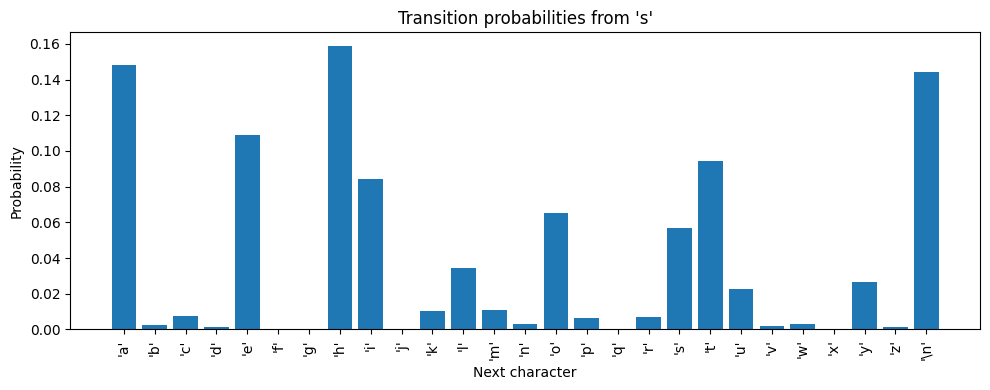

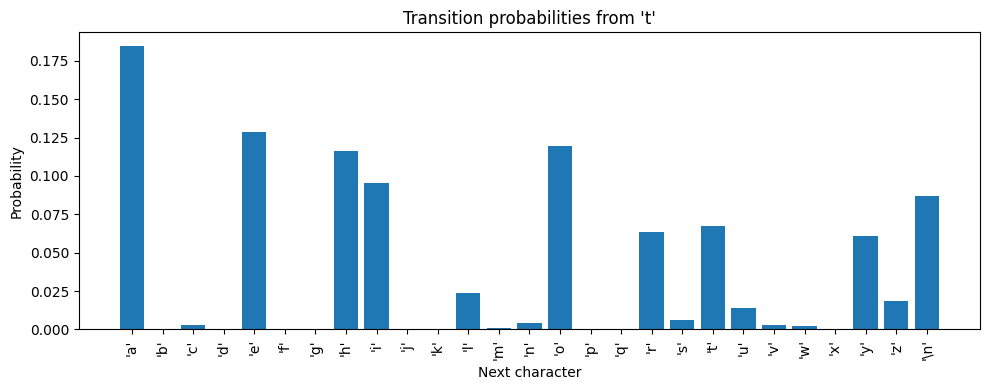

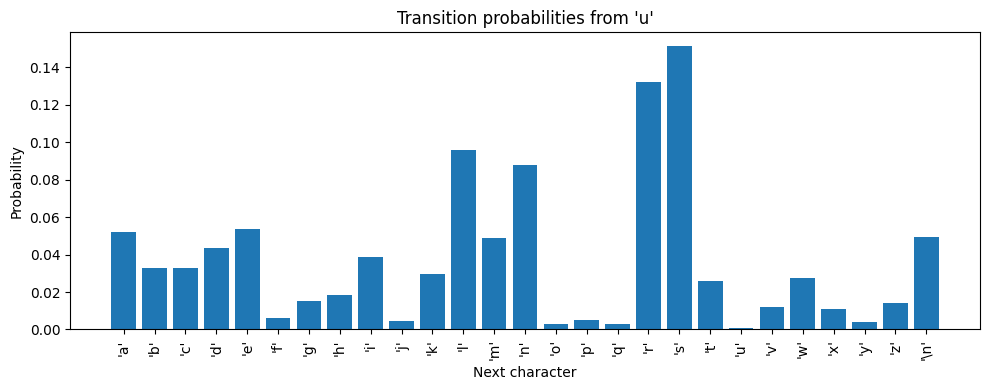

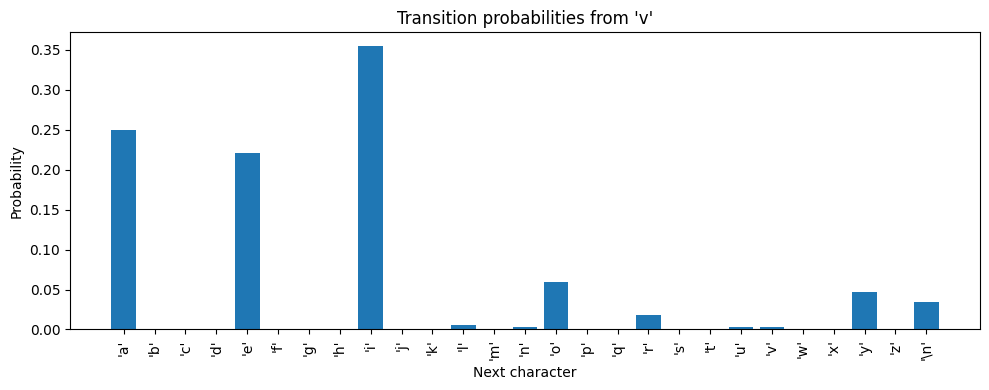

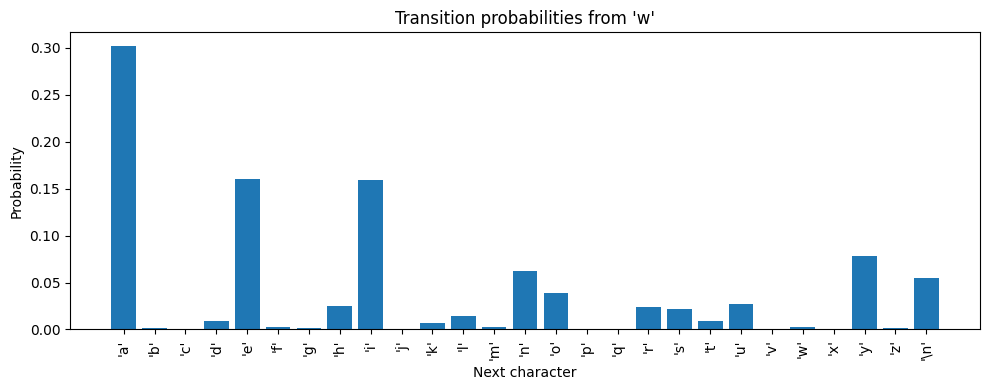

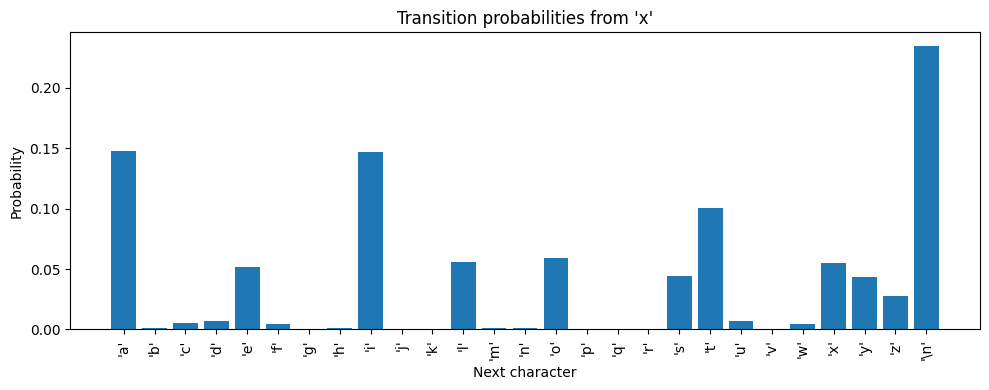

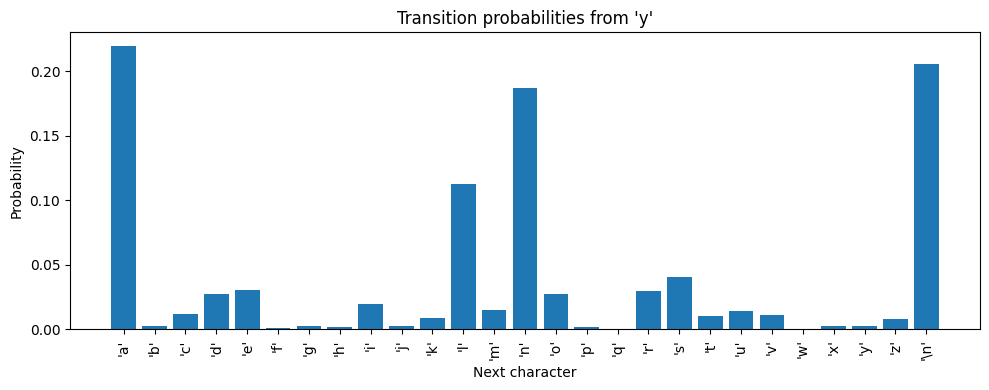

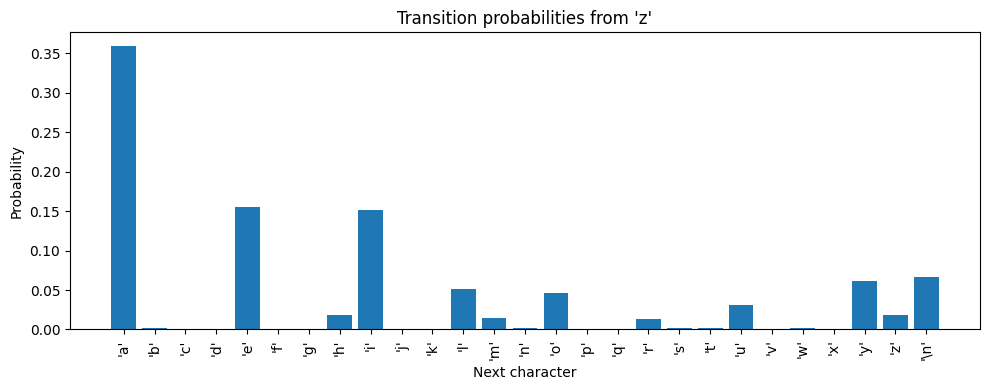

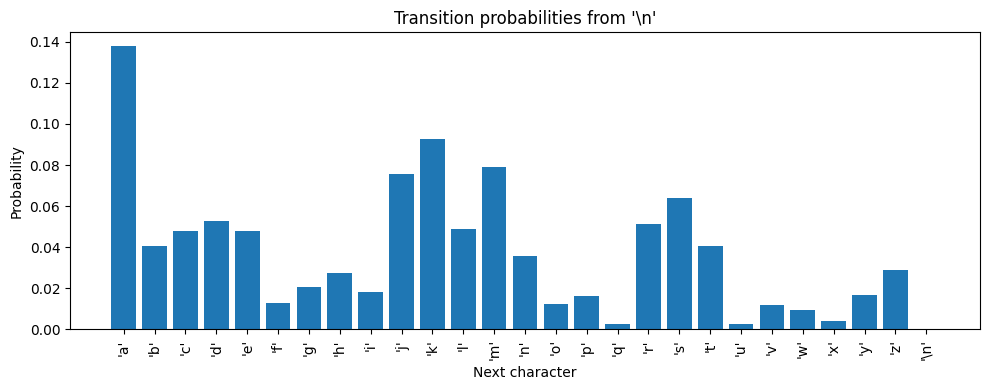

In [13]:
import matplotlib.pyplot as plt
import string
chars = string.ascii_lowercase + '\n'
for ch in chars:
    x = []
    y = []
    for nxt in chars:
        x.append(repr(nxt))   # shows '\n' properly
        y.append(pp_letters[ch][nxt])

    plt.figure(figsize=(10,4))
    plt.bar(x, y)

    plt.title(f"Transition probabilities from {repr(ch)}")
    plt.xlabel("Next character")
    plt.ylabel("Probability")

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

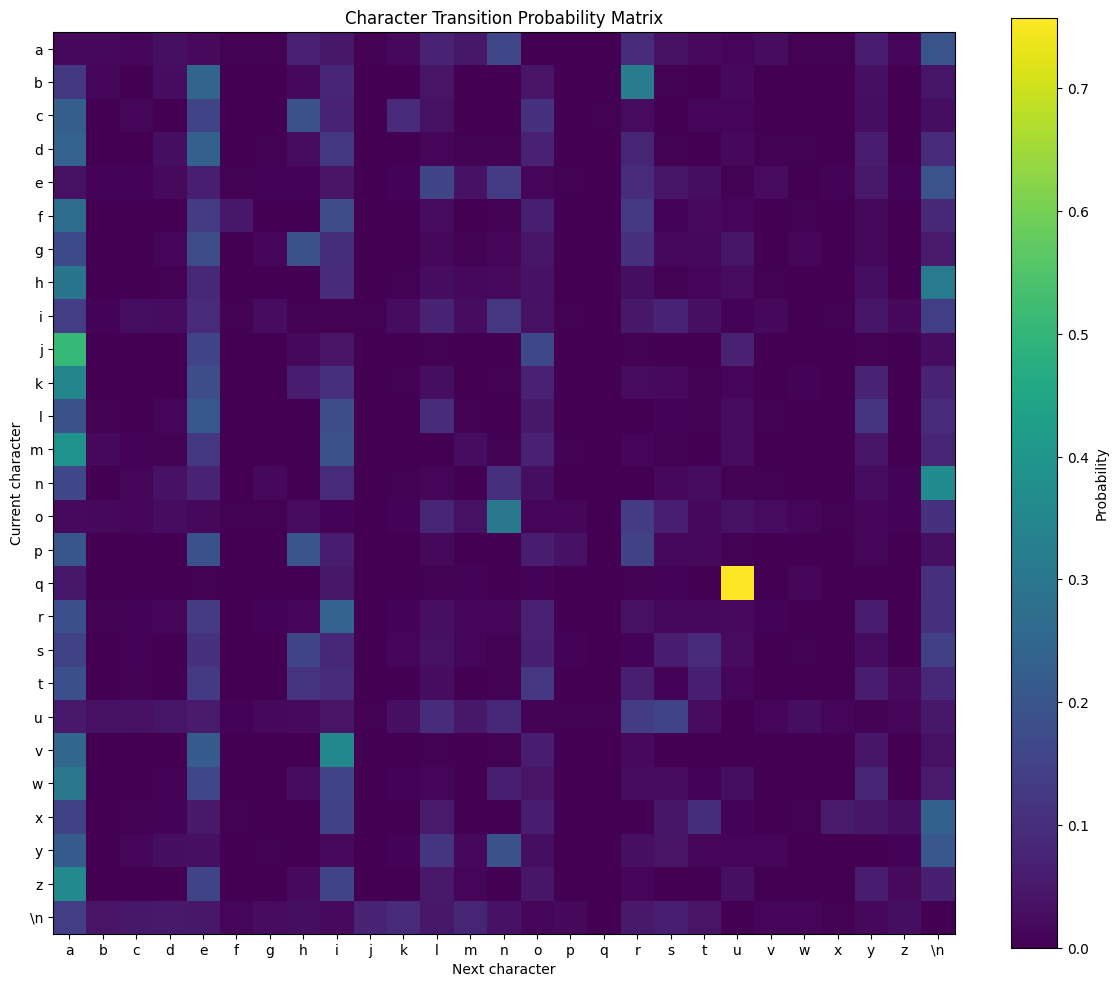

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import string

chars = list(string.ascii_lowercase + '\n')

mat = []

for ch in chars:
    row = []
    for nxt in chars:
        row.append(pp_letters[ch][nxt])
    mat.append(row)

mat = np.array(mat)

plt.figure(figsize=(12,10))

plt.imshow(mat)

plt.colorbar(label='Probability')

labels = [c if c != '\n' else '\\n' for c in chars]

plt.xticks(range(len(chars)), labels)
plt.yticks(range(len(chars)), labels)

plt.xlabel("Next character")
plt.ylabel("Current character")
plt.title("Character Transition Probability Matrix")

plt.tight_layout()
plt.show()

Now, we have a lot of information regarding the structure of names
we jsut need to use it

the heat map shows some green and a really bright yellow spot indicating that after q we can be almost sure that the next letter is u (can be confirmed from the pmf distribution)


In [15]:
# what i am thinking of is a word generation engine
# so basically fist we need to code a function which outputs word according to a given pmf (not only the hignerst ranked words but the whole pmf)

# one simple way i know of is scalling each of them to integers and then basically do a uniform random number genreator and map that range over this
# we can do the same thing mappend on (0,1) and then just defining ranges according to cdf

import random

cdf_letters = {}
for ch in pp_letters:
    cdf_letters[ch] = []
    cumulative = 0.0
    for nxt, prob in pp_letters[ch].items():
        cumulative += prob
        cdf_letters[ch].append((nxt, cumulative))

def sample(cdf):
    r = random.random()
    for ch, cutoff in cdf:
        if r <= cutoff:
            return ch



In [16]:
def generate_word():
    ch = '\n'   # start state
    word = ""
    while True:
        nxt = sample(cdf_letters[ch])
        if nxt == '\n':
            break
        word += nxt
        ch = nxt
    return word

for _ in range(20):
    print(generate_word())

drynonddamarcha
v
mah
kaggisolearahudelon
enise
ja
fayn
p
kdeba
nilyn
ky
n
murdroowah
xx
aiake
mola
ppestz
kle
sameracenit
ren


We see some meaning full names(nearly meaningful) atleast

zona \
sanny \
dan \
haakairo (wow ! japanese name) \
maha


Learning pytorch

I will try to implement the whole thing really but computationally more faster


In [30]:
# A @ B is really fast for gpus
# the main bottleneck is the overhead of memory movment
# Arithmetic Intensity=Bytes Moved / Operations​

# avoid for loops do vector operations on one kernel no cpu involvment



# let's look at the inefficiencies here

# first i have used dictionary which highly cache inefficient, one should try to use contigious memory blocks
# while the dictionary data structure use hashing(this also adds overhead) and stores across the memory
# we know the size of the dictionary before hand so we can just map to a contigious array

import torch
import string

chars = ['.'] + list(string.ascii_lowercase)

stoi = {ch: i for i, ch in enumerate(chars)} # basically enumerate returns a pair index,char
itos = {i: ch for ch, i in stoi.items()}

vocab_size = len(chars)

with open("names.txt") as f:
    words = f.read().splitlines()


# we initailise this count vector with N[i,j] = number of times character j follows character i

N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

# this loop was already pretty efficient (linear complexity)
for word in words:

    encoded = [0] + [stoi[ch] for ch in word] + [0]

    xs = encoded[:-1]
    ys = encoded[1:]

    for x, y in zip(xs, ys):
        N[x, y] += 1


# this is faster than the loop version
P = N.float()

P /= P.sum(dim=1, keepdim=True) # broadcasting


def generate_word():

    current = 0

    output = []

    while True:

        probs = P[current]

        next_idx = torch.multinomial(
            probs,
            num_samples=1,
            replacement=True
        ).item()

        if next_idx == 0:
            break

        output.append(itos[next_idx])

        current = next_idx

    return ''.join(output)


for _ in range(20):
    print(generate_word())

aishesho
eroe
zika
e
za
k
malinahari
mah
rtun
jalandely
jol
tyaubrillettalyaros
jarelan
ka
m
ria
konidouci
a
kaleolylcalldlerdylan
ra


In [25]:
# still two inefficiencies i was looking at karpathy's code and that's why i constructed the dictionaries stoi and itos
# but this still includes cache lookups for a dictionary at each letter of each word, now i understand this lookup is very small overhead but we are still inefficent
# we don't need to include hashing for mapping elements to indexes we can do that by a fucntion like f(char)-> index by return ord(char)-ord('a)+1


# the second inefficiency is the matrix construction linear conplexity code
# now the implementation is linear but there is a nested python loop which adds unecessary overhead, can we avoid it

#PyTorch is acting as a fast linear algebra library, but it's being choked by standard Python interpreter overhead



import torch

with open("names.txt", "r") as f:
    text = "." + ".".join(f.read().splitlines()) + "."

# Convert the entire string into a 1D tensor of ASCII bytes instantly
# This avoids Python loops and creates a contiguous memory block
bytes_tensor = torch.tensor([ord(c) for c in text], dtype=torch.long)

# use c++ backend for faster index conversion
tokens=torch.where(bytes_tensor==46, 0, bytes_tensor-96)

In [27]:
tokens.shape # this is a flattened vector

torch.Size([228147])

In [32]:
# Create input (xs) and target (ys) slices - this is an O(1) memory view!
xs = tokens[:-1]
ys = tokens[1:]

# Because we joined words with '.', we generated artificial '..' transitions.
# We must filter those out so they don't skew our bigram counts.
valid_mask = ~((xs == 0) & (ys == 0))
xs = xs[valid_mask]
ys = ys[valid_mask]

# Compress 2D coordinates (xs, ys) into a 1D array of flat indices
# This allows us to use the highly optimized torch.bincount kernel
vocab_size = 27
flat_indices = xs * vocab_size + ys


counts = torch.bincount(flat_indices, minlength=vocab_size * vocab_size)


N = counts.view(vocab_size, vocab_size).float() # . view doesn't copies

P = N / N.sum(dim=1, keepdim=True)

def generate_word():

    current = 0

    output = []

    while True:

        probs = P[current]

        next_idx = torch.multinomial(
            probs,
            num_samples=1,
            replacement=True
        ).item()

        if next_idx == 0:
            break

        output.append(itos[next_idx])

        current = next_idx

    return ''.join(output)


for _ in range(20):
    print(generate_word())

rinndanitelieloerilahrseceynnionniayaann
deloeylliah
jasto
asponasti
ciya
keasedinnai
khelerdachuzlon
chiarelama
camelalylietynilauin
ansilen
g
q
riori
n
fonthyndani
yeyaledilysene
quhatan
ky
mmiganatn
jol


 ### Summary: How `tensor.view()` Works (Zero-Copy Reshaping)

In PyTorch, a tensor consists of two separate components under the hood:
1. **The Storage:** A flat, contiguous 1D block of raw numbers allocated in RAM or GPU VRAM.
2. **The Metadata:** A small structure defining how to interpret that raw block (e.g., **Shape** and **Stride**).

When you execute `N = counts.view(27, 27)`, PyTorch **does not copy or move any data**. It leaves the raw storage entirely untouched. Instead, it creates a new metadata wrapper that points to the exact same memory block but changes how it is navigated.

---

### How PyTorch "Fakes" a 2D Matrix (Strides)

Because physical memory is always a flat 1D sequence, PyTorch uses **strides** to mimic multidimensional arrays. A stride tells PyTorch how many elements it must skip in the raw 1D storage to move 1 step along a given dimension.

#### 1. Before `.view()` (`counts` tensor)
* **Shape:** `[729]`
* **Stride:** `(1,)`
* **Interpretation:** To get to the next element, jump forward by `1` slot in raw memory.

#### 2. After `.view(27, 27)` (`N` tensor)
* **Shape:** `[27, 27]`
* **Stride:** `(27, 1)`
* **Interpretation:** * To move down **1 row**, skip **27** slots in the flat memory.
  * To move right **1 column**, skip **1** slot in the flat memory.

When you access `N[1, 2]`, PyTorch instantly calculates the flat memory address using the strides:
$$\text{Memory Index} = (\text{Row} \times \text{Stride}_0) + (\text{Column} \times \text{Stride}_1)$$
$$\text{Memory Index} = (1 \times 27) + (2 \times 1) = 29$$

---

### Why This Maximizes GPU Efficiency

* **$O(1)$ Constant Time:** Changing metadata takes a fraction of a nanosecond, whether the tensor has 700 elements or 7 billion.
* **Zero VRAM Allocation:** No extra memory is allocated, preventing allocation overhead and garbage collection.
* **Perfect Contiguity:** The data remains perfectly aligned and packed in memory. When a GPU thread blocks reads from `N`, it streams the elements sequentially, maximizing hardware memory bandwidth.

*(Note: Because they share the same storage, modifying a value in `N` will instantly change it in `counts` as well!)*

# **LOSS**

In [35]:
log_probs = torch.log(P + 1e-9)
# the small number i added is actaully done to prevent log reaching infinity but this is actually wrong because now the probability vectors won't
# normalise to 1 but for such small vector we are only off by 2.7*1e-8 which should be fine

co_occurrence_loss = N * log_probs

total_bigrams = N.sum()
nll_loss = -co_occurrence_loss.sum() / total_bigrams

print(f"Negative Log-Likelihood Loss: {nll_loss.item():.4f}")

Negative Log-Likelihood Loss: 2.4540


# **MLP**

Now let's do the same task using a mlp in hopes that a deep mlp might be abel to learn some important sturcture of ordering of letter of words


Moreover let's use micrograd for the weights training

In [17]:
# let's use the Value class to create layers
# so basically a Layer can be taken as a an array of values
# the mlp can also be constructed using the value class only but that would be too discrete

import random

class Layer:
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size

        # initialise random weight values
        self.weights = [[Value(random.uniform(-1, 1)) for _ in range(input_size)] for _ in range(output_size)]
        self.biases = [ Value(random.uniform(-1, 1)) for _ in range(output_size)]

    def __call__(self, x):
        outputs = []
        for w_row, b in zip(self.weights, self.biases):
            # weighted sum
            out = sum((wi * xi for wi, xi in zip(w_row, x)), b)
            # activation
            out = out.relu()
            outputs.append(out)
        return outputs
    # the weights and baises matrix
    def parameters(self):
        params = []
        for row in self.weights:
            params.extend(row)
        params.extend(self.biases)
        return params



In [18]:
# also MLP becomes

class MLP:

    def __init__(self, sizes):
        self.layers = []
        for i in range(len(sizes) - 1):
            self.layers.append(Layer(sizes[i], sizes[i+1]))

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    # collect all Value objects representing
    # weights and biases across the network
    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

In [19]:
net = MLP([3,1])

x = [Value(1.0), Value(2.0), Value(3.0)]

out = net(x)

print(out)


[Value(data=0, grad=0.0)]


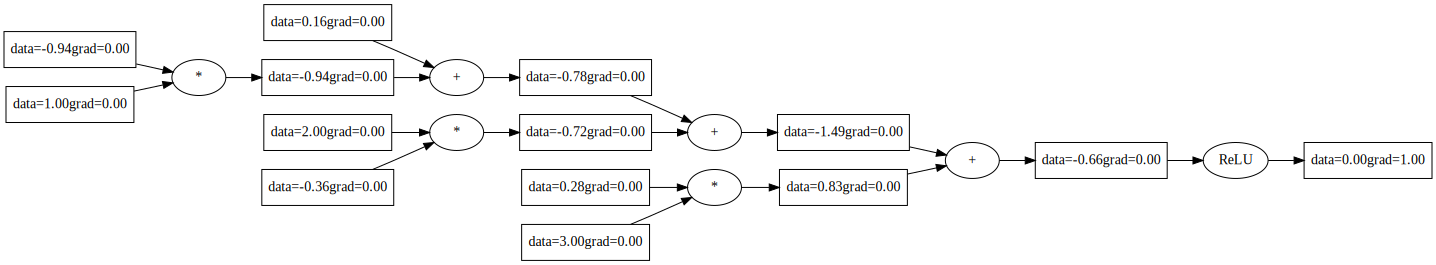

In [20]:
out[0].backward()
draw_dot(out[0])

In [21]:
# from git hub repo of Andrej Karpathy
import random

class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

In [36]:
# we have the xs and ys made
print(xs.shape)
print(ys.shape)

torch.Size([228146])
torch.Size([228146])


In [37]:
print(xs[0:10])
print(ys[0:10])

tensor([ 0,  5, 13, 13,  1,  0, 15, 12,  9, 22])
tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9])


In [41]:
xs.dtype,ys.dtype

(torch.int64, torch.int64)

In [44]:
# create one hot encodings
import torch.nn.functional as F

x_encoded=F.one_hot(xs,num_classes=27).float()
y_encoded=F.one_hot(ys,num_classes=27).float()

print(x_encoded.shape,y_encoded.shape)

torch.Size([228146, 27]) torch.Size([228146, 27])


In [ ]:
# let's reverse enginnering a neural network which uses a fixed bigram and see what it has learnt


# i will keep updating this file as i work on